Import Libraries

In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

Set Dataset Path

In [52]:
dataset_path = r"C:\Sem5-(TY)\Deep Learning\Deep Learning Labs\Assignment6\tomato\train"

Check the folders

In [53]:
print("Dataset path:", dataset_path)

print("\nClasses:")
for folder in os.listdir(dataset_path):
    print(folder)

Dataset path: C:\Sem5-(TY)\Deep Learning\Deep Learning Labs\Assignment6\tomato\train

Classes:
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus


Define Parameters

In [54]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

Load Training and Validation Dataset

In [55]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.


Check Classes

In [56]:
class_names = train_dataset.class_names

print("Class Names:")
for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

print("\nNumber of classes:", len(class_names))

Class Names:
0 : Tomato___Bacterial_spot
1 : Tomato___Early_blight
2 : Tomato___Late_blight
3 : Tomato___Leaf_Mold
4 : Tomato___Septoria_leaf_spot
5 : Tomato___Spider_mites Two-spotted_spider_mite
6 : Tomato___Target_Spot
7 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 : Tomato___Tomato_mosaic_virus
9 : Tomato___healthy

Number of classes: 10


Count Images

In [57]:
total_images = 0

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(f"{class_name}: {count} images")

    total_images += count

print("\nTotal Images:", total_images)

Tomato___Bacterial_spot: 1000 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1000 images
Tomato___Leaf_Mold: 1000 images
Tomato___Septoria_leaf_spot: 1000 images
Tomato___Spider_mites Two-spotted_spider_mite: 1000 images
Tomato___Target_Spot: 1000 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1000 images
Tomato___Tomato_mosaic_virus: 1000 images
Tomato___healthy: 1000 images

Total Images: 10000


Visualize Sample Images

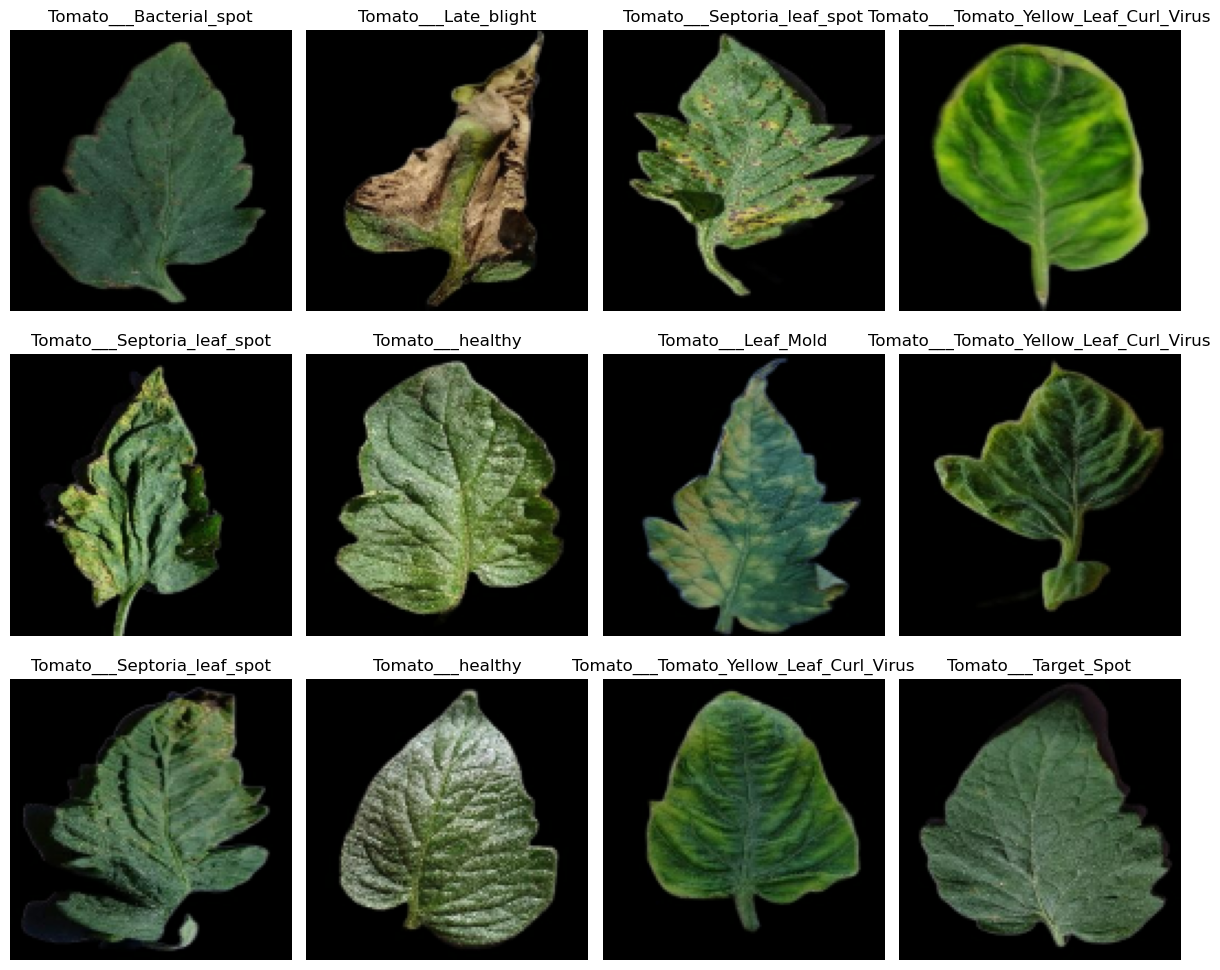

In [58]:
plt.figure(figsize=(12, 10))

for images, labels in train_dataset.take(1):

    for i in range(12):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

Data Augmentation

In [59]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

Build CNN Model

In [60]:
model = models.Sequential([

    # Input
    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels from 0-255 to 0-1
    layers.Rescaling(1./255),

    # -------------------------
    # Convolution Block 1
    # -------------------------
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # -------------------------
    # Convolution Block 2
    # -------------------------
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # -------------------------
    # Convolution Block 3
    # -------------------------
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # -------------------------
    # Classification
    # -------------------------
    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    # Prevent overfitting
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

Display CNN Architecture

In [61]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile the Model

In [62]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train the CNN

In [63]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 295ms/step - accuracy: 0.3320 - loss: 1.8426 - val_accuracy: 0.4980 - val_loss: 1.4534
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 301ms/step - accuracy: 0.5104 - loss: 1.3752 - val_accuracy: 0.5990 - val_loss: 1.1422
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 304ms/step - accuracy: 0.5746 - loss: 1.1931 - val_accuracy: 0.6635 - val_loss: 0.9330
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 74s 295ms/step - accuracy: 0.6308 - loss: 1.0571 - val_accuracy: 0.6645 - val_loss: 0.9743
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 303ms/step - accuracy: 0.6714 - loss: 0.9472 - val_accuracy: 0.6965 - val_loss: 0.8576
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.6913 - loss: 0.8791 - val_accuracy: 0.7260 - val_loss: 0.7508
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 314ms/step - accuracy: 0.7164 - loss: 0.8039 - val_accuracy: 0.7470 - val_loss: 0.6987
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 75s 300ms/step - accuracy: 0.7346 - loss: 0

Plot Training and Validation Accuracy

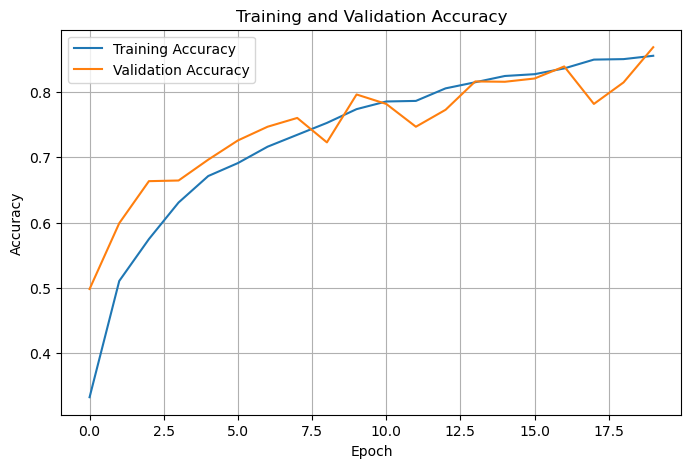

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

Plot Training and Validation Loss

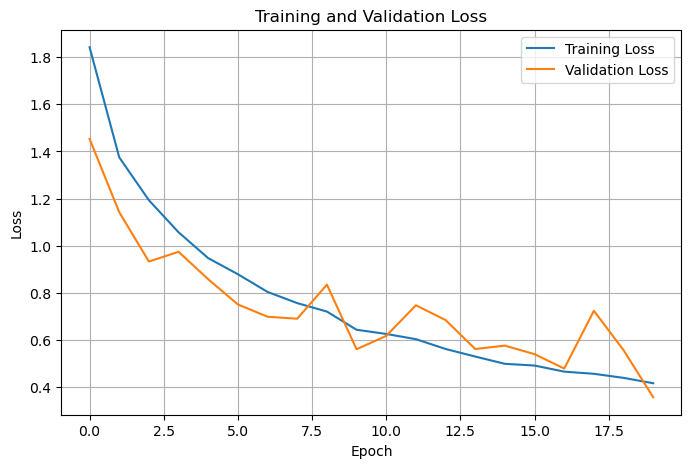

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

Evaluate Model

In [66]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("Validation Accuracy (%):", accuracy * 100)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.8690 - loss: 0.3571
Validation Loss: 0.3571054935455322
Validation Accuracy: 0.8690000176429749
Validation Accuracy (%): 86.90000176429749


Generate Predictions

In [67]:
y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")

Predictions generated successfully.


Classification Report

In [68]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.95      0.89      0.92       202
                        Tomato___Early_blight       0.83      0.72      0.77       198
                         Tomato___Late_blight       0.81      0.88      0.85       189
                           Tomato___Leaf_Mold       0.87      0.87      0.87       194
                  Tomato___Septoria_leaf_spot       0.76      0.79      0.78       197
Tomato___Spider_mites Two-spotted_spider_mite       0.93      0.81      0.87       200
                         Tomato___Target_Spot       0.82      0.81      0.82       200
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.93      0.97      0.95       219
                 Tomato___Tomato_mosaic_virus       0.90      0.99      0.95       201
                             Tomato___healthy       0.88      0.94      0.91       200

                                     accu

Confusion Matrix

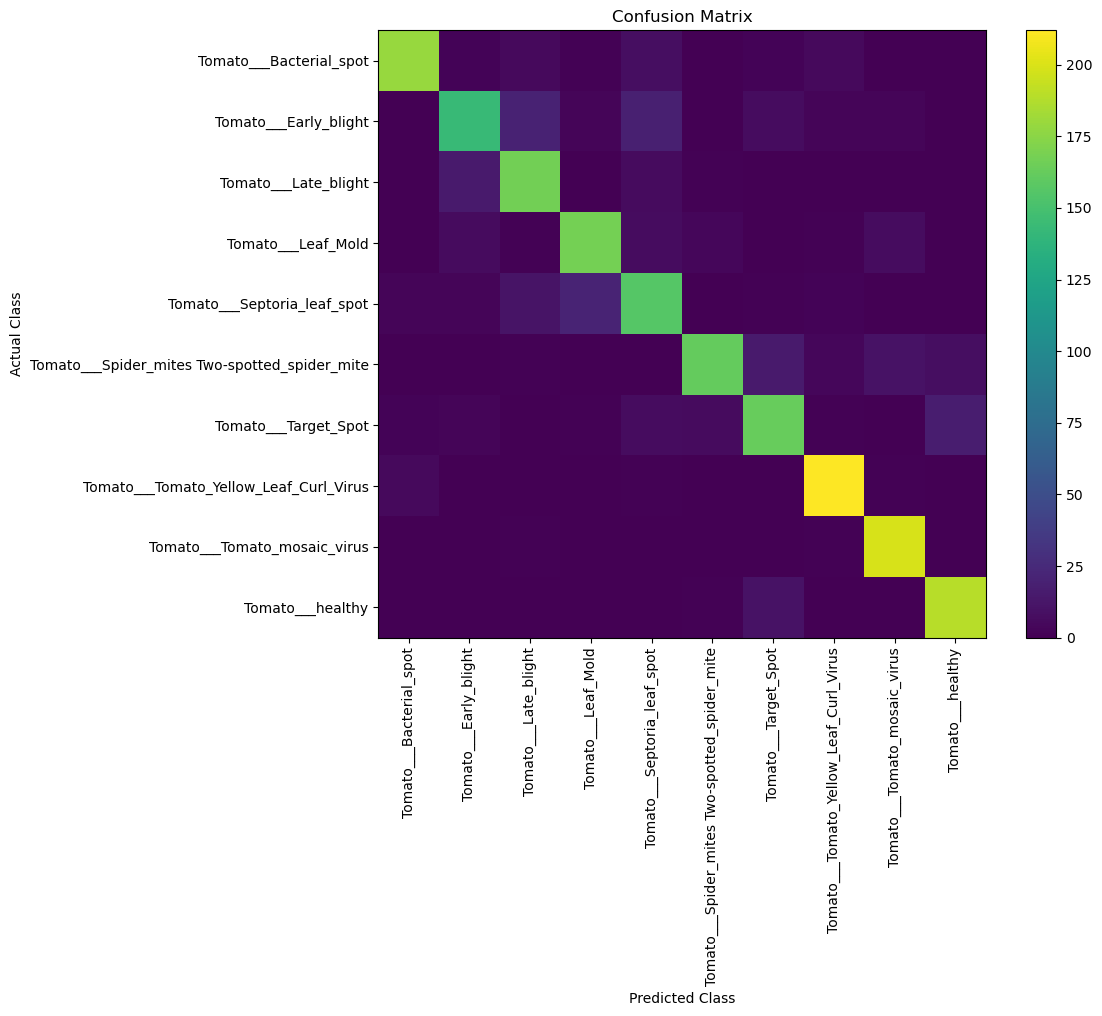

In [69]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()

plt.tight_layout()

plt.show()

Test a Single New Image

In [70]:
from tensorflow.keras.utils import load_img, img_to_array

image_path = r"C:\Sem5-(TY)\Deep Learning\Deep Learning Labs\Assignment6\tomato\train\Tomato___Bacterial_spot\33028adc-9dc2-4ac3-a7b9-7094200264f6___GCREC_Bact.Sp 3162.JPG"

img = load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(
    img_array,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Predicted Class: Tomato___Bacterial_spot
Confidence: 99.27 %


Display Prediction

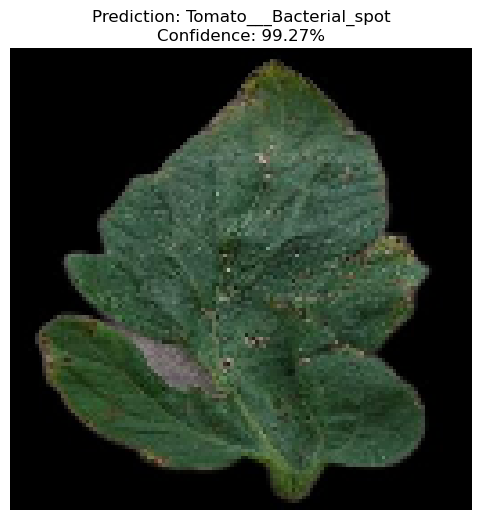

In [71]:
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

Show Prediction Probabilities for All Classes

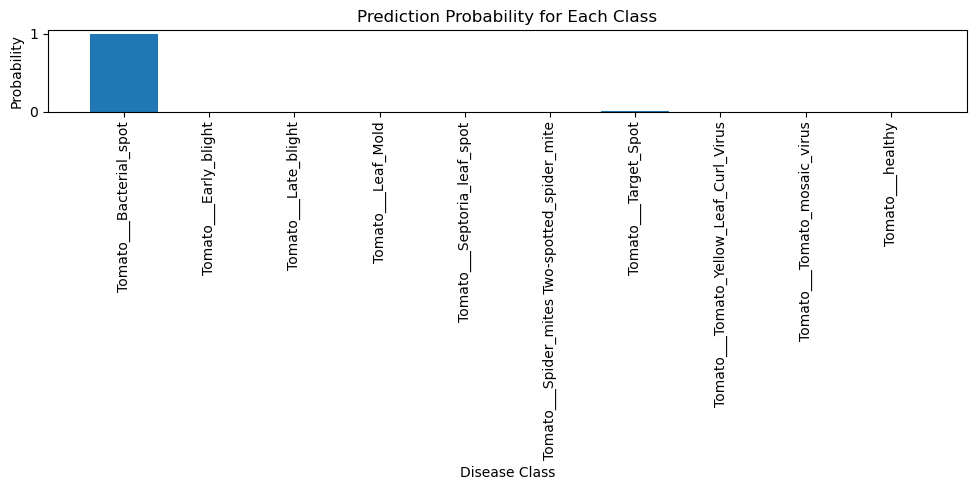

In [72]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_names,
    prediction[0]
)

plt.xticks(
    rotation=90
)

plt.ylabel("Probability")

plt.xlabel("Disease Class")

plt.title("Prediction Probability for Each Class")

plt.tight_layout()

plt.show()

Save the Trained Model

In [73]:
model.save("tomato_disease_cnn.keras")

print("Model saved successfully.")

Model saved successfully.


Final Model Information

In [74]:
print("===================================")
print("      TOMATO DISEASE CNN")
print("===================================")

print("Number of Classes:", len(class_names))
print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

print(
    "Validation Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print("===================================")

      TOMATO DISEASE CNN
Number of Classes: 10
Image Size: (128, 128)
Batch Size: 32
Epochs: 20
Validation Accuracy: 86.9 %
